In this notebook Seamese network model for handwriting author verification trained. As backbpn ResNet50 used with freezed parameters.

In [1]:
!pip install -q gdown

file_id = "1Cy_YHWkkPIJXlHwxa8TOGTKwqRWdBthz"
output_name = "patches_output.zip"

!gdown --id {file_id} -O {output_name}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Cy_YHWkkPIJXlHwxa8TOGTKwqRWdBthz
From (redirected): https://drive.google.com/uc?id=1Cy_YHWkkPIJXlHwxa8TOGTKwqRWdBthz&confirm=t&uuid=44ea2a5e-230d-4bc6-8945-18d68714eb20
To: /kaggle/working/patches_output.zip
100%|██████████████████████████████████████| 1.03G/1.03G [00:15<00:00, 66.2MB/s]


In [2]:
import zipfile
import os

with zipfile.ZipFile("patches_output.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/")

# Посмотрите, что получилось
os.listdir("/kaggle/working/")

['patches_output.zip', 'patches_output', '.virtual_documents']

In [3]:
DATA_ROOT = "/kaggle/working/patches_output"

In [4]:
!pip install torchvision

In [5]:
import os
from pathlib import Path
import cv2
import numpy as np
import shutil
import random
import torch

from torch.utils.data import Dataset
import PIL
from PIL import Image
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader

import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
def set_seed(seed=42):
    """Fix all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"All seeds fixed to {seed}")
set_seed(42)

All seeds fixed to 42


Let's create class SiameseNetworkDataset for our data.
The dataset takes random pairs and create either positive (one author) or negative pair. The labels are created at random, the balance shall be ~50/50.
The pairs are created 'on the fly'.

In [8]:
class SiameseNetworkDataset(Dataset):
    def __init__(self, root, transform=None, train=True, size=100,
                 min_height=100, max_height=500, authors_list=None):
        self.transform = transform
        self.train = train
        self.size = size
        self.min_height = min_height
        self.max_height = max_height

        self.authors_data_positive = {}
        self.authors_data_all = {}

        if authors_list is not None:
            folders_to_scan = [f for f in os.listdir(root) if f in authors_list]
        else:
            folders_to_scan = os.listdir(root)

        for folder in folders_to_scan:
            author_path = os.path.join(root, folder)
            if not os.path.isdir(author_path):
                continue

            valid_images = []
            for file in os.listdir(author_path):
                if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue

                img_path = os.path.join(author_path, file)
                try:
                    with Image.open(img_path) as img:
                        height = img.size[1]
                    if self.min_height <= height <= self.max_height:
                        valid_images.append(file)
                except Exception:
                    continue

            if not valid_images:
                continue

            self.authors_data_all[author_path] = valid_images
            if len(valid_images) >= 2:
                self.authors_data_positive[author_path] = valid_images

        self.authors_paths_positive = list(self.authors_data_positive.keys())
        self.authors_paths_all = list(self.authors_data_all.keys())

        print(f"  Positive authors (>=2 images): {len(self.authors_paths_positive)}")
        print(f"  Total authors: {len(self.authors_paths_all)}")

        if len(self.authors_paths_positive) == 0:
            raise ValueError("No authors with at least 2 valid images!")

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        #creating labelfrom random.
        label = random.randint(0, 1)

        if label == 1:
            # Positive pair: same author
            author_path = random.choice(self.authors_paths_positive)
            images = self.authors_data_positive[author_path]
            img1_name, img2_name = random.sample(images, 2)
            img_path1 = os.path.join(author_path, img1_name)
            img_path2 = os.path.join(author_path, img2_name)

        else:
            #create negative pair
            if len(self.authors_paths_all) < 2:
                author_path = random.choice(self.authors_paths_positive)
                images = self.authors_data_positive[author_path]
                img1_name, img2_name = random.sample(images, 2)
                img_path1 = os.path.join(author_path, img1_name)
                img_path2 = os.path.join(author_path, img2_name)
                label = 1
            else:
                author1_path, author2_path = random.sample(self.authors_paths_all, 2)
                images1 = self.authors_data_all[author1_path]
                images2 = self.authors_data_all[author2_path]

                img1_name = random.choice(images1)
                img2_name = random.choice(images2)

                img_path1 = os.path.join(author1_path, img1_name)
                img_path2 = os.path.join(author2_path, img2_name)


        img1 = Image.open(img_path1).convert('L')
        img2 = Image.open(img_path2).convert('L')

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label

In [9]:
#splitting authors into train and val
import random
all_authors = [f for f in os.listdir(DATA_ROOT)
               if os.path.isdir(os.path.join(DATA_ROOT, f))]
random.shuffle(all_authors)

split_idx = int(len(all_authors) * 0.8)
train_authors = all_authors[:split_idx]
val_authors = all_authors[split_idx:]

print(f"Train authors: {len(train_authors)}, Val authors: {len(val_authors)}")

Train authors: 525, Val authors: 132


In [10]:
class ResizeTextPatch:
    """
    Adaptive resize of wide patches.
    Preserve propotions target_h × target_w.
    """
    def __init__(self, target_h=192, target_w=512):
        self.target_h = target_h
        self.target_w = target_w

    def __call__(self, img):
        w, h = img.size  # PIL: width, height

        # Calculating scale
        scale_h = self.target_h / h
        scale_w = self.target_w / w
        scale = min(scale_h, scale_w)

        new_w = int(w * scale)
        new_h = int(h * scale)

        # Resizing with interpolation
        img = TF.resize(img, [new_h, new_w], interpolation=TF.InterpolationMode.BICUBIC)

        # Creating black square
        new_img = Image.new('L', (self.target_w, self.target_h), 0)

        # Centerring the image
        paste_x = (self.target_w - new_w) // 2
        paste_y = (self.target_h - new_h) // 2
        new_img.paste(img, (paste_x, paste_y))

        return new_img

In [11]:
train_transform = T.Compose([

    ResizeTextPatch(target_h=384, target_w=1014),
    T.RandomRotation(3),
    T.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    T.ToTensor(),
    T.Normalize(mean=[0.485], std=[0.229])  # ImageNet stats for 1 channel
])

val_transform = T.Compose([
    ResizeTextPatch(target_h=384, target_w=1014),
    T.ToTensor(),
    T.Normalize(mean=[0.485], std=[0.229])
])

In [12]:
train_dataset = SiameseNetworkDataset(
    root=DATA_ROOT,
    transform=train_transform,
    train=True,
    size=2500,
    min_height=100,
    max_height=500,
    authors_list=train_authors
)

val_dataset = SiameseNetworkDataset(
    root=DATA_ROOT,
    transform=val_transform,
    train=False,
    size=2000,
    min_height=100,
    max_height=500,
    authors_list=val_authors
)

  Positive authors (>=2 images): 426
  Total authors: 516
  Positive authors (>=2 images): 109
  Total authors: 128


Lbael: 1
Size img1: torch.Size([1, 384, 1014])
Size img2: torch.Size([1, 384, 1014])


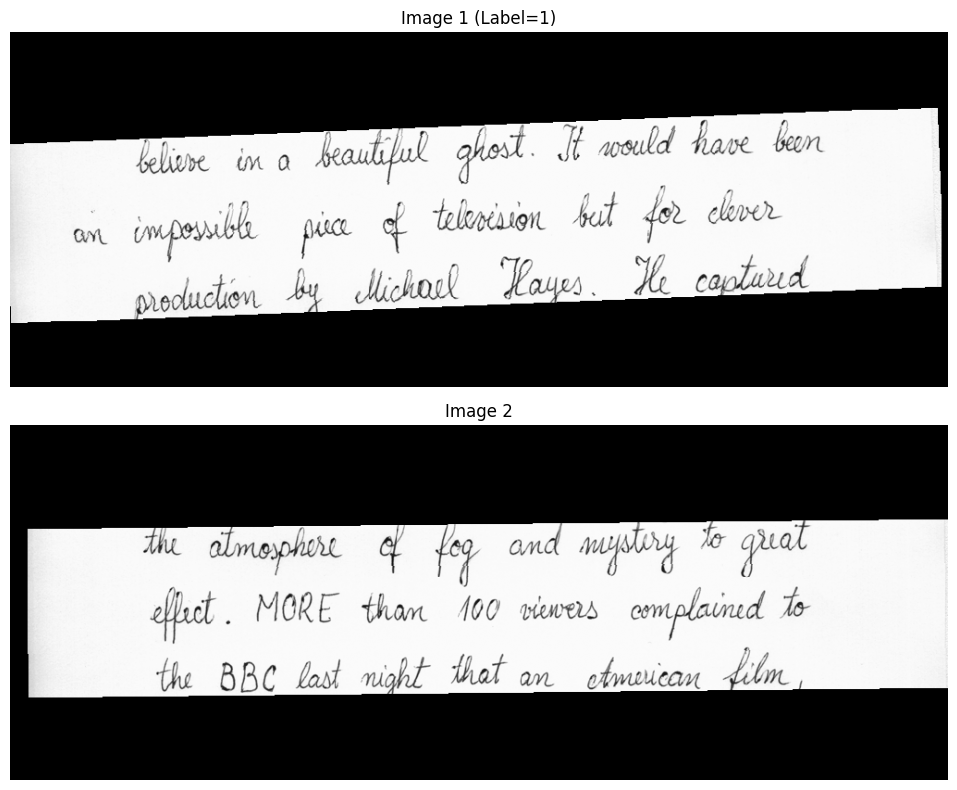

In [13]:
img1, img2, label = train_dataset[3]

print(f"Lbael: {label}")
print(f"Size img1: {img1.shape}")
print(f"Size img2: {img2.shape}")

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.imshow(img1[0], cmap='gray')
plt.title(f"Image 1 (Label={label})")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img2[0], cmap='gray')
plt.title("Image 2")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
labels=[]

for i in range(len(train_dataset)):
  labels.append(train_dataset[i][2])

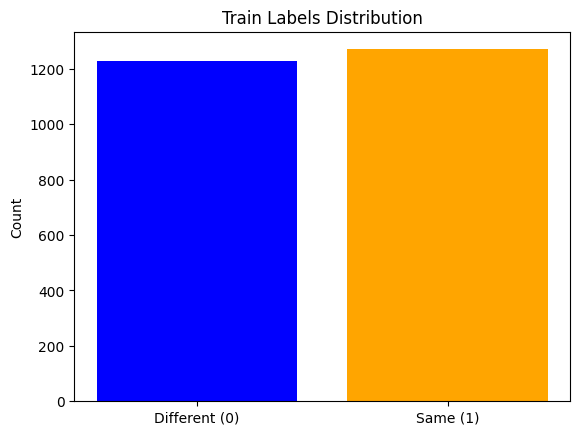

In [ ]:
counts = [labels.count(0), labels.count(1)]

plt.bar(['Different (0)', 'Same (1)'], counts, color=['blue', 'orange'])
plt.ylabel('Count')
plt.title('Train Labels Distribution')
plt.show()

In [16]:
# creating DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Let's create class for our model. The class has freeze_mode parameter (aggressive or moderate), in aggressive mode we freeze all layer except for the last one, in moderate except for 2 lasts.For training we use Contrastive loss+BCE

In [18]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_size=256, freeze_mode="aggressive"):
        super(SiameseNetwork, self).__init__()

        # Load pretrained ResNet-50
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Adapt first layer for single channel
        original_conv1 = backbone.conv1
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        backbone.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)

        # Remove final FC layer
        self.resnet = nn.Sequential(*list(backbone.children())[:-1])

        # Freeze layers based on mode
        if freeze_mode == "aggressive":
            # Freeze all layers
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreeze layer4 (index 7) and conv1 (index 0)
            # layer4 parameters are under index 7
            for name, param in self.resnet.named_parameters():
                if name.startswith('7.'):  # layer4
                    param.requires_grad = True

            # Unfreeze conv1 (index 0)
            for param in self.resnet[0].parameters():
                param.requires_grad = True

        elif freeze_mode == "moderate":
            # Freeze all layers first
            for param in self.resnet.parameters():
                param.requires_grad = False

            # Unfreeze layer3 (index 6) and layer4 (index 7)
            for name, param in self.resnet.named_parameters():
                if name.startswith('6.') or name.startswith('7.'):  # layer3 and layer4
                    param.requires_grad = True

            # Unfreeze conv1 (index 0)
            for param in self.resnet[0].parameters():
                param.requires_grad = True

        elif freeze_mode == "none":
            # All layers trainable
            pass

        # Embedding head
        self.embedding = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, embedding_size)
        )

        # Classifier head
        self.classifier = nn.Linear(embedding_size, 1)

        self.embedding_size = embedding_size

        # Print statistics
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Freeze mode: {freeze_mode}")
        print(f"Total parameters: {total:,}")
        print(f"Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)")

    def forward_one(self, x):
        x = self.resnet(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        return F.normalize(x, p=2, dim=1)

    def forward(self, x1, x2):
        out1 = self.forward_one(x1)
        out2 = self.forward_one(x2)
        distance = torch.abs(out1 - out2)
        logits = self.classifier(distance).squeeze(1)
        return logits, out1, out2

In [19]:
class ContrastiveLoss(nn.Module):
    """Contrastive loss"""

    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Eucledian distance
        distance = F.pairwise_distance(output1, output2)

        loss = label * torch.pow(distance, 2) / 2
        loss += (1 - label) * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2) / 2

        return loss.mean()

In [20]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=0.001,
    device=None,
    save_path='best_model.pth',
    weight_decay=weight_decay
):
    """Training Siamese network with fixed contrastive loss"""

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Move model to device
    model = model.to(device)

    # Optimizer and scheduler
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, threshold = 0.01
    )

    # Loss functions
    contrastive_loss = ContrastiveLoss(margin=1.0)
    bce_loss = nn.BCEWithLogitsLoss()

    # History tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_roc_auc': [], 'val_roc_auc': [],
        'lr': []
    }
    best_val_roc_auc = 0.0

    for epoch in range(epochs):
        # training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_labels = []
        train_preds = []


        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for img1, img2, labels in pbar:
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.float().to(device)

            optimizer.zero_grad()
            logits, emb1, emb2 = model(img1, img2)

            loss_contrastive = contrastive_loss(emb1, emb2, labels)
            loss_bce = bce_loss(logits, labels)
            loss = loss_contrastive + loss_bce

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            probs = torch.sigmoid(logits)
            predicted = (probs > 0.5).float()
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)

            train_labels.extend(labels.cpu().numpy())
            train_preds.extend(probs.detach().cpu().numpy())  # use probs for ROC-AUC

            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{train_correct/train_total:.3f}'
                }
            )

        train_acc = train_correct / train_total
        train_loss_avg = train_loss / len(train_loader)
        train_roc_auc = roc_auc_score(train_labels, train_preds)


        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_labels = []
        val_preds = []


        with torch.no_grad():
            for img1, img2, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                img1 = img1.to(device)
                img2 = img2.to(device)
                labels = labels.float().to(device)

                logits, emb1, emb2 = model(img1, img2)

                loss_contrastive = contrastive_loss(emb1, emb2, labels)
                loss_bce = bce_loss(logits, labels)
                loss = loss_contrastive + 0.05 * loss_bce

                val_loss += loss.item()

                probs = torch.sigmoid(logits)
                predicted = (probs > 0.5).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                val_labels.extend(labels.cpu().numpy())
                val_preds.extend(probs.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss_avg = val_loss / len(val_loader)
        val_roc_auc = roc_auc_score(val_labels, val_preds)

        # Update scheduler
        scheduler.step(val_loss_avg)

        # Save history
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_roc_auc'].append(train_roc_auc)
        history['val_roc_auc'].append(val_roc_auc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # Print results
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss_avg:.4f}, Train Acc: {train_acc:.4f}, ROC-AUC: {train_roc_auc:.4f}")
        print(f"  Val Loss:   {val_loss_avg:.4f}, Val Acc:   {val_acc:.4f}, ROC-AUC: {val_roc_auc:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model by ROC-AUC
        if val_roc_auc > best_val_roc_auc:
            best_val_roc_auc = val_roc_auc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_roc_auc': val_roc_auc
            }, save_path)
            print(f"Model saved. Val Acc: {val_acc:.4f}, Val ROC-AUC: {val_roc_auc:.4f}")

    return history

In [ ]:
model = SiameseNetwork(embedding_size=256, freeze_mode='aggressive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_scratch.pth',
    weight_decay=0.0001)

print(f"\nBest Val ROC-AUC: {max(history['val_roc_auc'])*100:.2f}%")

Freeze mode: aggressive
Total parameters: 25,862,593
Trainable parameters: 17,328,705 (67.0%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [02:43<00:00,  1.53it/s]



Epoch 1/30
  Train Loss: 0.7703, Train Acc: 0.5012, ROC-AUC: 0.6275
  Val Loss:   0.1208, Val Acc:   0.6805, ROC-AUC: 0.8350
  LR: 0.001000
Model saved. Val Acc: 0.6805, Val ROC-AUC: 0.8350


Epoch 2/30 [Val]: 100%|██████████| 250/250 [02:43<00:00,  1.53it/s]



Epoch 2/30
  Train Loss: 0.6858, Train Acc: 0.6940, ROC-AUC: 0.7776
  Val Loss:   0.1039, Val Acc:   0.7770, ROC-AUC: 0.8751
  LR: 0.001000
Model saved. Val Acc: 0.7770, Val ROC-AUC: 0.8751


...


Epoch 19/30
  Train Loss: 0.4189, Train Acc: 0.8548, ROC-AUC: 0.9063
  Val Loss:   0.0715, Val Acc:   0.8355, ROC-AUC: 0.9321
  LR: 0.000500


Epoch 20/30 [Val]: 100%|██████████| 250/250 [02:43<00:00,  1.53it/s]



Epoch 20/30
  Train Loss: 0.4199, Train Acc: 0.8544, ROC-AUC: 0.9087
  Val Loss:   0.0717, Val Acc:   0.8240, ROC-AUC: 0.9290
  LR: 0.000500


Epoch 21/30 [Train]:  23%|██▎       | 72/313 [01:57<06:32,  1.63s/it, loss=0.4667, acc=0.839]


KeyboardInterrupt: 

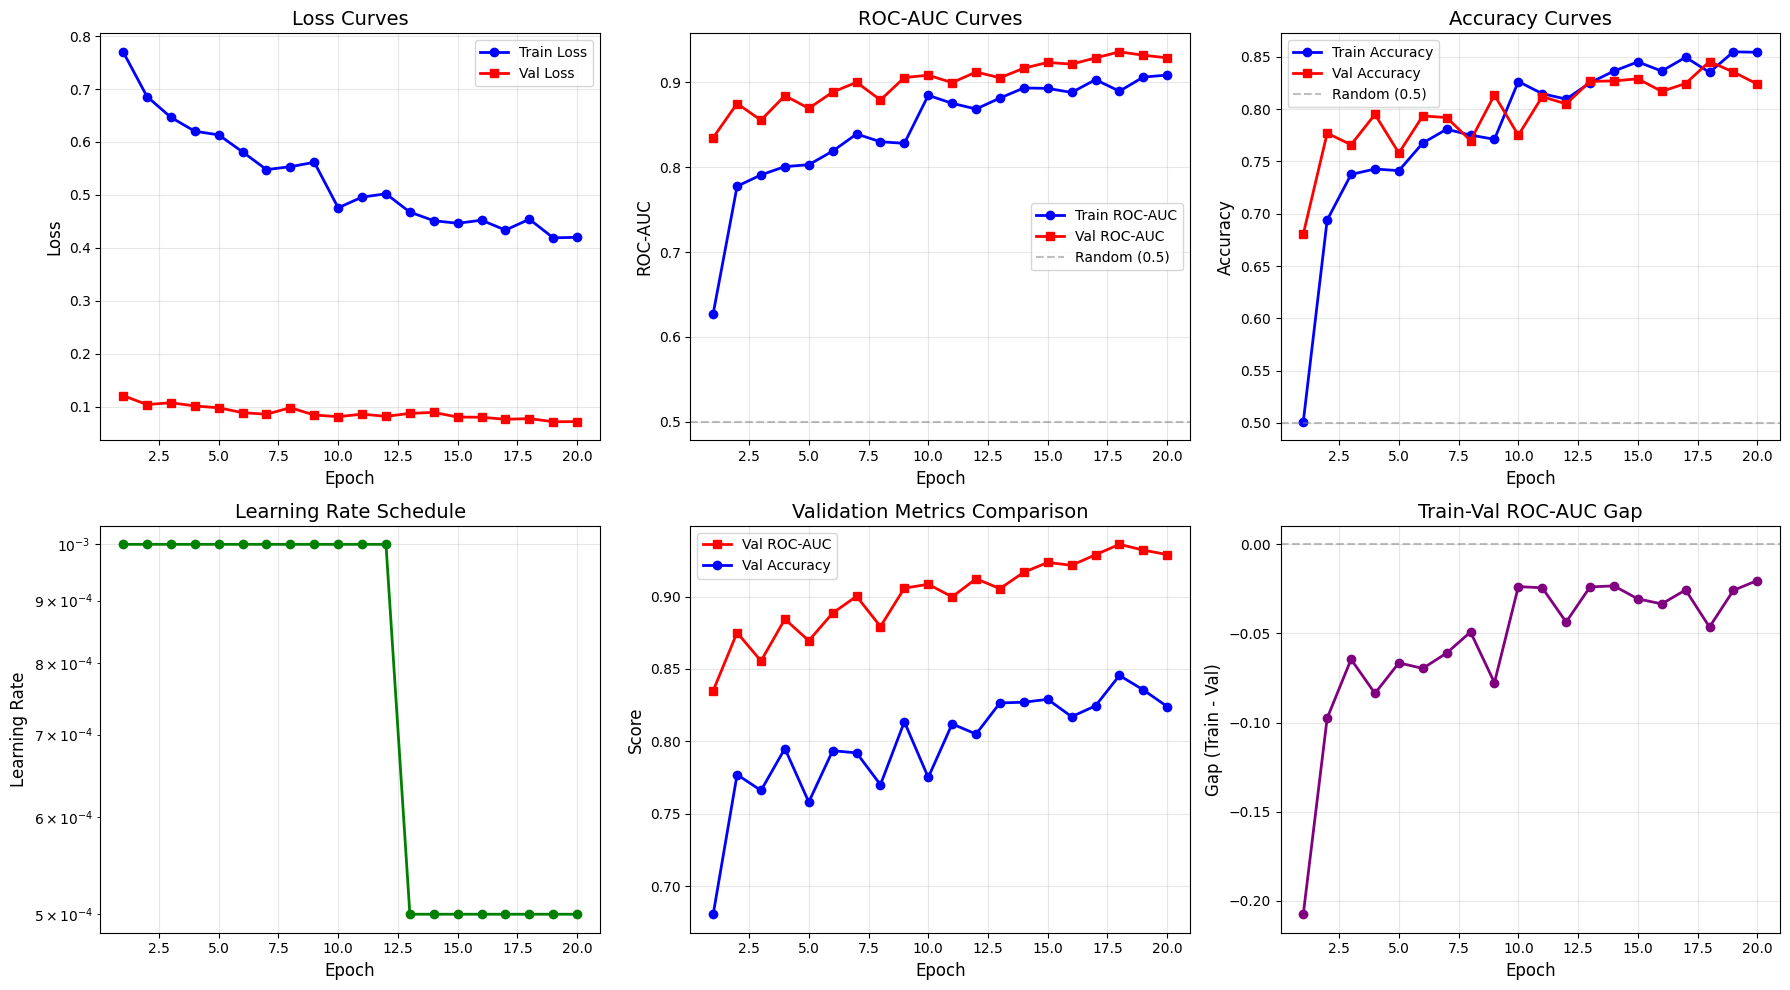

In [27]:
epochs = list(range(1, 21))

train_loss = [
    0.7703, 0.6858, 0.6465, 0.6203, 0.6134,
    0.5812, 0.5478, 0.5533, 0.5616, 0.4756,
    0.4959, 0.5021, 0.4675, 0.4513, 0.4464,
    0.4522, 0.4335, 0.4541, 0.4189, 0.4199
]

val_loss = [
    0.1208, 0.1039, 0.1074, 0.1013, 0.0978,
    0.0886, 0.0857, 0.0980, 0.0842, 0.0810,
    0.0859, 0.0816, 0.0873, 0.0891, 0.0803,
    0.0800, 0.0761, 0.0774, 0.0715, 0.0717
]

train_acc = [
    0.5012, 0.6940, 0.7376, 0.7428, 0.7412,
    0.7676, 0.7808, 0.7752, 0.7712, 0.8264,
    0.8148, 0.8096, 0.8252, 0.8364, 0.8452,
    0.8364, 0.8496, 0.8352, 0.8548, 0.8544
]

val_acc = [
    0.6805, 0.7770, 0.7660, 0.7950, 0.7580,
    0.7935, 0.7920, 0.7700, 0.8135, 0.7750,
    0.8120, 0.8050, 0.8265, 0.8270, 0.8290,
    0.8170, 0.8245, 0.8455, 0.8355, 0.8240
]

train_roc_auc = [
    0.6275, 0.7776, 0.7910, 0.8008, 0.8030,
    0.8190, 0.8392, 0.8301, 0.8282, 0.8848,
    0.8754, 0.8687, 0.8816, 0.8935, 0.8930,
    0.8882, 0.9033, 0.8897, 0.9063, 0.9087
]

val_roc_auc = [
    0.8350, 0.8751, 0.8555, 0.8844, 0.8695,
    0.8886, 0.9002, 0.8793, 0.9058, 0.9085,
    0.8998, 0.9123, 0.9055, 0.9168, 0.9236,
    0.9216, 0.9289, 0.9361, 0.9321, 0.9290
]

lr = [
    0.001, 0.001, 0.001, 0.001, 0.001,
    0.001, 0.001, 0.001, 0.001, 0.001,
    0.001, 0.001, 0.0005, 0.0005, 0.0005,
    0.0005, 0.0005, 0.0005, 0.0005, 0.0005
]

# Create figure with 2x3 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Loss Curves
axes[0, 0].plot(epochs, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=6)
axes[0, 0].plot(epochs, val_loss, 'r-s', label='Val Loss', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Loss Curves', fontsize=14)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. ROC-AUC Curves
axes[0, 1].plot(epochs, train_roc_auc, 'b-o', label='Train ROC-AUC', linewidth=2, markersize=6)
axes[0, 1].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=6)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('ROC-AUC', fontsize=12)
axes[0, 1].set_title('ROC-AUC Curves', fontsize=14)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. Accuracy Curves
axes[0, 2].plot(epochs, train_acc, 'b-o', label='Train Accuracy', linewidth=2, markersize=6)
axes[0, 2].plot(epochs, val_acc, 'r-s', label='Val Accuracy', linewidth=2, markersize=6)
axes[0, 2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 2].set_xlabel('Epoch', fontsize=12)
axes[0, 2].set_ylabel('Accuracy', fontsize=12)
axes[0, 2].set_title('Accuracy Curves', fontsize=14)
axes[0, 2].legend(fontsize=10)
axes[0, 2].grid(True, alpha=0.3)

# 4. Learning Rate Schedule
axes[1, 0].plot(epochs, lr, 'g-o', linewidth=2, markersize=6)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
axes[1, 0].set_title('Learning Rate Schedule', fontsize=14)
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# 5. Combined Metrics (ROC-AUC + Accuracy)
axes[1, 1].plot(epochs, val_roc_auc, 'r-s', label='Val ROC-AUC', linewidth=2, markersize=6)
axes[1, 1].plot(epochs, val_acc, 'b-o', label='Val Accuracy', linewidth=2, markersize=6)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Score', fontsize=12)
axes[1, 1].set_title('Validation Metrics Comparison', fontsize=14)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# 6. Train vs Val Gap (ROC-AUC difference)
gap = [train_roc_auc[i] - val_roc_auc[i] for i in range(len(epochs))]
axes[1, 2].plot(epochs, gap, 'purple', marker='o', linewidth=2, markersize=6)
axes[1, 2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 2].set_xlabel('Epoch', fontsize=12)
axes[1, 2].set_ylabel('Gap (Train - Val)', fontsize=12)
axes[1, 2].set_title('Train-Val ROC-AUC Gap', fontsize=14)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_aggressive.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
model = SiameseNetwork(embedding_size=256, freeze_mode='moderate')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Train
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=0.001,
    device=device,
    save_path='best_model_scratch.pth')

print(f"\nBest Val ROC-AUC: {max(history['val_roc_auc'])*100:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 234MB/s]


Freeze mode: moderate
Total parameters: 25,862,593
Trainable parameters: 24,427,073 (94.4%)


Epoch 1/30 [Val]: 100%|██████████| 250/250 [02:26<00:00,  1.71it/s]



Epoch 1/30
  Train Loss: 0.7876, Train Acc: 0.5100, ROC-AUC: 0.5876
  Val Loss:   0.1303, Val Acc:   0.7035, ROC-AUC: 0.8434
  LR: 0.001000
Model saved. Val Acc: 0.7035, Val ROC-AUC: 0.8434


...


Epoch 28/30
  Train Loss: 0.4207, Train Acc: 0.8612, ROC-AUC: 0.9095
  Val Loss:   0.0860, Val Acc:   0.7800, ROC-AUC: 0.8998
  LR: 0.000031


Epoch 29/30 [Val]: 100%|██████████| 250/250 [02:26<00:00,  1.71it/s]



Epoch 29/30
  Train Loss: 0.4111, Train Acc: 0.8568, ROC-AUC: 0.9118
  Val Loss:   0.0801, Val Acc:   0.7685, ROC-AUC: 0.9051
  LR: 0.000031


Epoch 30/30 [Val]: 100%|██████████| 250/250 [02:26<00:00,  1.71it/s]


Epoch 30/30
  Train Loss: 0.4028, Train Acc: 0.8668, ROC-AUC: 0.9173
  Val Loss:   0.0827, Val Acc:   0.7720, ROC-AUC: 0.9070
  LR: 0.000031

Best Val ROC-AUC: 91.16%


In [22]:
history

{'train_loss': [0.7875919229687213,
  0.7064490585852736,
  0.6512318955252345,
  0.6208537900790619,
  0.6199058312387131,
  0.583914148064848,
  0.5778602965342732,
  0.5548639645020421,
  0.5466861698193292,
  0.53083661179573,
  0.5090940738924015,
  0.5045386977469959,
  0.4898374719075121,
  0.4720191247404193,
  0.46975888947423655,
  0.47926555590602915,
  0.4462462688525454,
  0.4470030651829494,
  0.44156062264983265,
  0.44209099689516396,
  0.44164359745697473,
  0.4449043297729553,
  0.4280477043586417,
  0.46005765084451,
  0.40895387725517773,
  0.4248328510279092,
  0.4005568646870482,
  0.42065159210000935,
  0.41111623824309235,
  0.40278786175643294],
 'val_loss': [0.13026413056254388,
  0.10257999103516341,
  0.10402278147265315,
  0.08976334512978792,
  0.09602138967067003,
  0.09390514075011015,
  0.09145462615042925,
  0.08550142020359636,
  0.10222150151431561,
  0.08242583067342639,
  0.08509816117212177,
  0.09393759144842624,
  0.08648053837940096,
  0.088025

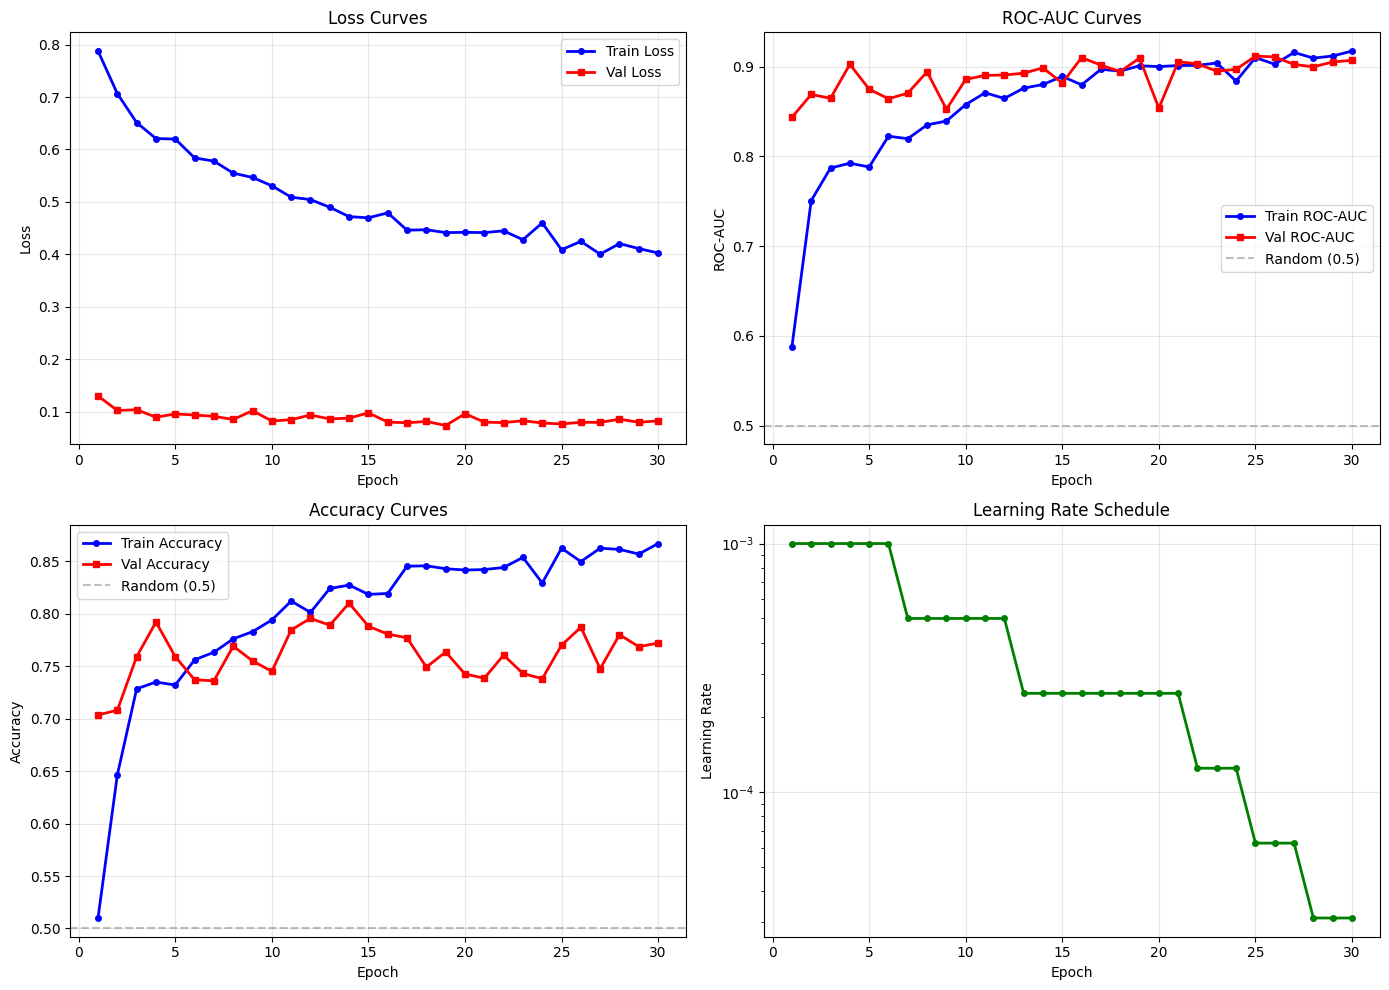

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

# 1. Loss Curves
axes[0, 0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history['val_loss'], 'r-s', label='Val Loss', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curves')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. ROC-AUC Curves
axes[0, 1].plot(epochs, history['train_roc_auc'], 'b-o', label='Train ROC-AUC', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history['val_roc_auc'], 'r-s', label='Val ROC-AUC', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('ROC-AUC')
axes[0, 1].set_title('ROC-AUC Curves')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Accuracy Curves
axes[1, 0].plot(epochs, history['train_acc'], 'b-o', label='Train Accuracy', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, history['val_acc'], 'r-s', label='Val Accuracy', linewidth=2, markersize=4)
axes[1, 0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy Curves')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Learning Rate Schedule
axes[1, 1].plot(epochs, history['lr'], 'g-o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics_moderate.png', dpi=150, bbox_inches='tight')
plt.show()


